In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
from pathlib import Path

data_path = Path("../data/raw/PS_20174392719_1491204439457_log.csv")

print("File exists:", data_path.exists())
print("File path:", data_path.resolve())

File exists: True
File path: /Users/kunalsingh/banking-fraud-analytics/data/raw/PS_20174392719_1491204439457_log.csv


In [3]:
sample = pd.read_csv(data_path, nrows=10)

sample

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [4]:
print("Columns:")
print(sample.columns.tolist())

print("\nNumber of columns:", sample.shape[1])

print("\nData types:")
print(sample.dtypes)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Number of columns: 11

Data types:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [5]:
transaction_types = pd.read_csv(
    data_path,
    usecols=["type"]
)

print(transaction_types["type"].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [6]:
fraud_labels = pd.read_csv(
    data_path,
    usecols=["isFraud", "isFlaggedFraud"]
)

fraud_counts = fraud_labels["isFraud"].value_counts()

print("Fraud distribution:")
print(fraud_counts)

print("\nTotal transactions:", len(fraud_labels))
print("Fraudulent transactions:", fraud_labels["isFraud"].sum())

fraud_rate = fraud_labels["isFraud"].mean() * 100

print(f"\nFraud rate: {fraud_rate:.4f}%")

Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Total transactions: 6362620
Fraudulent transactions: 8213

Fraud rate: 0.1291%


In [7]:
fraud_by_type = pd.read_csv(
    data_path,
    usecols=["type", "isFraud"]
)

fraud_type_summary = (
    fraud_by_type
    .groupby("type")["isFraud"]
    .agg(
        total_transactions="count",
        fraud_transactions="sum"
    )
)

fraud_type_summary["fraud_rate_pct"] = (
    fraud_type_summary["fraud_transactions"]
    / fraud_type_summary["total_transactions"]
    * 100
)

fraud_type_summary.sort_values(
    "fraud_transactions",
    ascending=False
)

,total_transactions,fraud_transactions,fraud_rate_pct
type,,,
CASH_OUT,2237500,4116,0.183955
TRANSFER,532909,4097,0.768799
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


In [8]:
amount_analysis = pd.read_csv(
    data_path,
    usecols=["amount", "isFraud"]
)

amount_summary = (
    amount_analysis
    .groupby("isFraud")["amount"]
    .agg(["count", "mean", "median", "min", "max"])
)

amount_summary

,count,mean,median,min,max
isFraud,,,,,
0,6354407,1.781970e+05,74684.72,0.01,92445516.64
1,8213,1.467967e+06,441423.44,0.00,10000000.00


In [9]:
type_amount_analysis = pd.read_csv(
    data_path,
    usecols=["type", "amount", "isFraud"]
)

fraud_type_amount = (
    type_amount_analysis[
        type_amount_analysis["type"].isin(["TRANSFER", "CASH_OUT"])
    ]
    .groupby(["type", "isFraud"])["amount"]
    .agg(["count", "mean", "median"])
    .round(2)
)

fraud_type_amount

count        mean     median
type     isFraud                                
CASH_OUT 0        2233384   173917.16  146946.56
         1           4116  1455102.59  435516.90
TRANSFER 0         528812   906229.01  486521.91
         1           4097  1480891.67  445705.76

In [10]:
balance_analysis = pd.read_csv(
    data_path,
    usecols=[
        "type",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "isFraud"
    ]
)

balance_analysis["expected_newbalanceOrig"] = (
    balance_analysis["oldbalanceOrg"] - balance_analysis["amount"]
)

balance_analysis["orig_balance_error"] = (
    balance_analysis["newbalanceOrig"]
    - balance_analysis["expected_newbalanceOrig"]
).abs()

balance_analysis[
    [
        "type",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "expected_newbalanceOrig",
        "orig_balance_error",
        "isFraud"
    ]
].head(10)

,type,amount,oldbalanceOrg,newbalanceOrig,expected_newbalanceOrig,orig_balance_error,isFraud
0,PAYMENT,9839.64,170136.00,160296.36,160296.36,0.000000e+00,0
1,PAYMENT,1864.28,21249.00,19384.72,19384.72,0.000000e+00,0
2,TRANSFER,181.00,181.00,0.00,0.00,0.000000e+00,1
3,CASH_OUT,181.00,181.00,0.00,0.00,0.000000e+00,1
4,PAYMENT,11668.14,41554.00,29885.86,29885.86,0.000000e+00,0
5,PAYMENT,7817.71,53860.00,46042.29,46042.29,0.000000e+00,0
6,PAYMENT,7107.77,183195.00,176087.23,176087.23,0.000000e+00,0
7,PAYMENT,7861.64,176087.23,168225.59,168225.59,0.000000e+00,0
8,PAYMENT,4024.36,2671.00,0.00,-1353.36,1.353360e+03,0
9,DEBIT,5337.77,41720.00,36382.23,36382.23,7.275958e-12,0


In [11]:
balance_error_summary = (
    balance_analysis
    .groupby("isFraud")["orig_balance_error"]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)

balance_error_summary

,count,mean,median,max
isFraud,,,,
0,6354407,201338.56,69049.31,92445516.64
1,8213,10692.33,0.00,10000000.00


In [12]:
balance_analysis["has_orig_balance_error"] = (
    balance_analysis["orig_balance_error"] > 0.01
)

error_rate_summary = (
    balance_analysis
    .groupby("isFraud")["has_orig_balance_error"]
    .agg(["count", "sum", "mean"])
)

error_rate_summary["error_rate_pct"] = (
    error_rate_summary["mean"] * 100
).round(4)

error_rate_summary

,count,sum,mean,error_rate_pct
isFraud,,,,
0,6354407,5077646,0.799075,79.9075
1,8213,45,0.005479,0.5479


In [13]:
fraud_relevant_balance = balance_analysis[
    balance_analysis["type"].isin(["TRANSFER", "CASH_OUT"])
].copy()

balance_error_by_type = (
    fraud_relevant_balance
    .groupby(["type", "isFraud"])["orig_balance_error"]
    .agg(["count", "mean", "median"])
    .round(2)
)

balance_error_by_type

count       mean     median
type     isFraud                               
CASH_OUT 0        2233384  147994.19  119824.22
         1           4116    1306.13       0.00
TRANSFER 0         528812  873050.62  454033.08
         1           4097   20122.05       0.00

In [14]:
fraud_relevant_balance["has_orig_balance_error"] = (
    fraud_relevant_balance["orig_balance_error"] > 0.01
)

balance_error_rate_by_type = (
    fraud_relevant_balance
    .groupby(["type", "isFraud"])["has_orig_balance_error"]
    .agg(["count", "sum", "mean"])
)

balance_error_rate_by_type["error_rate_pct"] = (
    balance_error_rate_by_type["mean"] * 100
).round(4)

balance_error_rate_by_type

count      sum      mean  error_rate_pct
type     isFraud                                            
CASH_OUT 0        2233384  1991245  0.891582         89.1582
         1           4116       24  0.005831          0.5831
TRANSFER 0         528812   508761  0.962083         96.2083
         1           4097       21  0.005126          0.5126

In [15]:
destination_balance = pd.read_csv(
    data_path,
    usecols=[
        "type",
        "amount",
        "oldbalanceDest",
        "newbalanceDest",
        "isFraud"
    ]
)

destination_balance["expected_newbalanceDest"] = (
    destination_balance["oldbalanceDest"]
    + destination_balance["amount"]
)

destination_balance["dest_balance_error"] = (
    destination_balance["newbalanceDest"]
    - destination_balance["expected_newbalanceDest"]
).abs()

destination_balance[
    [
        "type",
        "amount",
        "oldbalanceDest",
        "newbalanceDest",
        "expected_newbalanceDest",
        "dest_balance_error",
        "isFraud"
    ]
].head(10)

,type,amount,oldbalanceDest,newbalanceDest,expected_newbalanceDest,dest_balance_error,isFraud
0,PAYMENT,9839.64,0.0,0.00,9839.64,9839.64,0
1,PAYMENT,1864.28,0.0,0.00,1864.28,1864.28,0
2,TRANSFER,181.00,0.0,0.00,181.00,181.00,1
3,CASH_OUT,181.00,21182.0,0.00,21363.00,21363.00,1
4,PAYMENT,11668.14,0.0,0.00,11668.14,11668.14,0
5,PAYMENT,7817.71,0.0,0.00,7817.71,7817.71,0
6,PAYMENT,7107.77,0.0,0.00,7107.77,7107.77,0
7,PAYMENT,7861.64,0.0,0.00,7861.64,7861.64,0
8,PAYMENT,4024.36,0.0,0.00,4024.36,4024.36,0
9,DEBIT,5337.77,41898.0,40348.79,47235.77,6886.98,0


In [16]:
fraud_relevant_dest = destination_balance[
    destination_balance["type"].isin(["TRANSFER", "CASH_OUT"])
].copy()

dest_error_by_type = (
    fraud_relevant_dest
    .groupby(["type", "isFraud"])["dest_balance_error"]
    .agg(["count", "mean", "median"])
    .round(2)
)

dest_error_by_type

count        mean     median
type     isFraud                                
CASH_OUT 0        2233384    30313.27       0.00
         1           4116    13965.04       0.00
TRANSFER 0         528812   103385.45       0.00
         1           4097  1479702.98  443893.69

In [17]:
fraud_relevant_dest["has_dest_balance_error"] = (
    fraud_relevant_dest["dest_balance_error"] > 0.01
)

dest_error_rate_by_type = (
    fraud_relevant_dest
    .groupby(["type", "isFraud"])["has_dest_balance_error"]
    .agg(["count", "sum", "mean"])
)

dest_error_rate_by_type["error_rate_pct"] = (
    dest_error_rate_by_type["mean"] * 100
).round(4)

dest_error_rate_by_type

count     sum      mean  error_rate_pct
type     isFraud                                           
CASH_OUT 0        2233384  506881  0.226956         22.6956
         1           4116     545  0.132410         13.2410
TRANSFER 0         528812  116716  0.220714         22.0714
         1           4097    4095  0.999512         99.9512

In [18]:
flag_analysis = pd.read_csv(
    data_path,
    usecols=["isFraud", "isFlaggedFraud"]
)

flag_summary = pd.crosstab(
    flag_analysis["isFraud"],
    flag_analysis["isFlaggedFraud"],
    margins=True
)

flag_summary

isFlaggedFraud,0,1,All
isFraud,,,
0,6354407,0,6354407
1,8197,16,8213
All,6362604,16,6362620


In [19]:
flagged_transactions = pd.read_csv(
    data_path,
    usecols=[
        "type",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
        "isFraud",
        "isFlaggedFraud"
    ]
)

flagged_transactions = flagged_transactions[
    flagged_transactions["isFlaggedFraud"] == 1
]

print("Number of flagged transactions:", len(flagged_transactions))

flagged_transactions

Number of flagged transactions: 16


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736446,TRANSFER,4953893.08,4953893.08,4953893.08,0.0,0.0,1,1
3247297,TRANSFER,1343002.08,1343002.08,1343002.08,0.0,0.0,1,1
3760288,TRANSFER,536624.41,536624.41,536624.41,0.0,0.0,1,1
5563713,TRANSFER,4892193.09,4892193.09,4892193.09,0.0,0.0,1,1
5996407,TRANSFER,10000000.00,19585040.37,19585040.37,0.0,0.0,1,1
5996409,TRANSFER,9585040.37,19585040.37,19585040.37,0.0,0.0,1,1
6168499,TRANSFER,3576297.10,3576297.10,3576297.10,0.0,0.0,1,1
6205439,TRANSFER,353874.22,353874.22,353874.22,0.0,0.0,1,1
6266413,TRANSFER,2542664.27,2542664.27,2542664.27,0.0,0.0,1,1
6281482,TRANSFER,10000000.00,10399045.08,10399045.08,0.0,0.0,1,1


In [20]:
model_data = pd.read_csv(
    data_path,
    usecols=[
        "step",
        "type",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
        "isFraud"
    ]
)

# Keep transaction types where fraud actually occurs
model_data = model_data[
    model_data["type"].isin(["TRANSFER", "CASH_OUT"])
].copy()

print("Model dataset shape:", model_data.shape)

print("\nTransaction types:")
print(model_data["type"].value_counts())

print("\nFraud distribution:")
print(model_data["isFraud"].value_counts())

print("\nFraud percentage:")
print(
    (model_data["isFraud"].mean() * 100).round(4),
    "%"
)

model_data.head()

Model dataset shape: (2770409, 8)

Transaction types:
type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

Fraud distribution:
isFraud
0    2762196
1       8213
Name: count, dtype: int64

Fraud percentage:
0.2965 %


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
2,1,TRANSFER,181.00,181.0,0.0,0.0,0.00,1
3,1,CASH_OUT,181.00,181.0,0.0,21182.0,0.00,1
15,1,CASH_OUT,229133.94,15325.0,0.0,5083.0,51513.44,0
19,1,TRANSFER,215310.30,705.0,0.0,22425.0,0.00,0
24,1,TRANSFER,311685.89,10835.0,0.0,6267.0,2719172.89,0


In [21]:
# ---------------------------------------------------------
# FEATURE ENGINEERING
# ---------------------------------------------------------

# 1. Origin balance error
# Expected:
# old balance - transaction amount = new balance

model_data["orig_balance_error"] = abs(
    (model_data["oldbalanceOrg"] - model_data["amount"])
    - model_data["newbalanceOrig"]
)


# 2. Destination balance error
# Expected:
# old destination balance + transaction amount = new balance

model_data["dest_balance_error"] = abs(
    (model_data["oldbalanceDest"] + model_data["amount"])
    - model_data["newbalanceDest"]
)


# 3. Did the transaction empty the origin account?
model_data["origin_emptied"] = (
    model_data["newbalanceOrig"] == 0
).astype(int)


# 4. Was the transaction amount equal to the entire
# available origin balance?
model_data["amount_equals_oldbalance"] = (
    abs(model_data["amount"] - model_data["oldbalanceOrg"]) < 0.01
).astype(int)


# 5. Transaction amount relative to origin balance
# Avoid division by zero
model_data["amount_to_balance_ratio"] = (
    model_data["amount"]
    / model_data["oldbalanceOrg"].replace(0, float("nan"))
)


# Replace undefined ratios with 0
model_data["amount_to_balance_ratio"] = (
    model_data["amount_to_balance_ratio"]
    .fillna(0)
)


# 6. Convert transaction type into a numeric feature
# TRANSFER = 1
# CASH_OUT = 0

model_data["is_transfer"] = (
    model_data["type"] == "TRANSFER"
).astype(int)


print("New dataset shape:", model_data.shape)

model_data[
    [
        "type",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "orig_balance_error",
        "dest_balance_error",
        "origin_emptied",
        "amount_equals_oldbalance",
        "amount_to_balance_ratio",
        "is_transfer",
        "isFraud"
    ]
].head(10)

New dataset shape: (2770409, 14)


,type,amount,oldbalanceOrg,newbalanceOrig,orig_balance_error,dest_balance_error,origin_emptied,amount_equals_oldbalance,amount_to_balance_ratio,is_transfer,isFraud
2,TRANSFER,181.00,181.00,0.0,0.000000e+00,181.00,1,1,1.000000,1,1
3,CASH_OUT,181.00,181.00,0.0,0.000000e+00,21363.00,1,1,1.000000,0,1
15,CASH_OUT,229133.94,15325.00,0.0,2.138089e+05,182703.50,1,0,14.951644,0,0
19,TRANSFER,215310.30,705.00,0.0,2.146053e+05,237735.30,1,0,305.404681,1,0
24,TRANSFER,311685.89,10835.00,0.0,3.008509e+05,2401220.00,1,0,28.766580,1,0
42,CASH_OUT,110414.71,26845.41,0.0,8.356930e+04,396799.55,1,0,4.112983,0,0
47,CASH_OUT,56953.90,1942.02,0.0,5.501188e+04,63100.72,1,0,29.327144,0,0
48,CASH_OUT,5346.89,0.00,0.0,5.346890e+03,5795447.02,1,0,0.000000,0,0
51,CASH_OUT,23261.30,20411.53,0.0,2.849770e+03,49003.30,1,0,1.139616,0,0
58,TRANSFER,62610.80,79114.00,16503.2,3.637979e-12,54744.51,0,0,0.791400,1,0


In [22]:
# ---------------------------------------------------------
# ENGINEERED FEATURE ANALYSIS: FRAUD VS NON-FRAUD
# ---------------------------------------------------------

feature_summary = (
    model_data
    .groupby("isFraud")
    .agg(
        transactions=("isFraud", "size"),

        avg_amount=("amount", "mean"),
        median_amount=("amount", "median"),

        avg_orig_balance_error=("orig_balance_error", "mean"),
        median_orig_balance_error=("orig_balance_error", "median"),

        avg_dest_balance_error=("dest_balance_error", "mean"),
        median_dest_balance_error=("dest_balance_error", "median"),

        origin_emptied_pct=("origin_emptied", "mean"),

        amount_equals_balance_pct=(
            "amount_equals_oldbalance", "mean"
        ),

        avg_amount_balance_ratio=(
            "amount_to_balance_ratio", "mean"
        ),

        transfer_pct=("is_transfer", "mean")
    )
)

# Convert binary proportions into percentages
feature_summary[
    [
        "origin_emptied_pct",
        "amount_equals_balance_pct",
        "transfer_pct"
    ]
] *= 100

feature_summary.round(2)

,transactions,avg_amount,median_amount,avg_orig_balance_error,median_orig_balance_error,avg_dest_balance_error,median_dest_balance_error,origin_emptied_pct,amount_equals_balance_pct,avg_amount_balance_ratio,transfer_pct
isFraud,,,,,,,,,,,
0,2762196,314115.5,171034.46,286803.51,144200.83,44302.66,0.00,90.10,0.00,145.97,19.14
1,8213,1467967.3,441423.44,10692.33,0.00,745138.59,9511.69,98.05,97.82,0.99,49.88


In [23]:
# ---------------------------------------------------------
# FRAUD RATE BY KEY BEHAVIOURAL FEATURES
# ---------------------------------------------------------

origin_emptied_analysis = (
    model_data
    .groupby("origin_emptied")
    .agg(
        transactions=("isFraud", "size"),
        fraud_transactions=("isFraud", "sum"),
        fraud_rate=("isFraud", "mean")
    )
)

origin_emptied_analysis["fraud_rate_pct"] = (
    origin_emptied_analysis["fraud_rate"] * 100
)

print("Fraud rate by whether origin account was emptied:")
display(origin_emptied_analysis.round(4))


amount_equals_analysis = (
    model_data
    .groupby("amount_equals_oldbalance")
    .agg(
        transactions=("isFraud", "size"),
        fraud_transactions=("isFraud", "sum"),
        fraud_rate=("isFraud", "mean")
    )
)

amount_equals_analysis["fraud_rate_pct"] = (
    amount_equals_analysis["fraud_rate"] * 100
)

print("\nFraud rate when transaction amount equals origin balance:")
display(amount_equals_analysis.round(4))

Fraud rate by whether origin account was emptied:


,transactions,fraud_transactions,fraud_rate,fraud_rate_pct
origin_emptied,,,,
0,273753,160,0.0006,0.0584
1,2496656,8053,0.0032,0.3226



Fraud rate when transaction amount equals origin balance:


,transactions,fraud_transactions,fraud_rate,fraud_rate_pct
amount_equals_oldbalance,,,,
0,2762375,179,0.0001,0.0065
1,8034,8034,1.0000,100.0000


In [24]:
# ---------------------------------------------------------
# INVESTIGATE FRAUD CASES THAT DO NOT EMPTY EXACT BALANCE
# ---------------------------------------------------------

remaining_fraud = model_data[
    (model_data["isFraud"] == 1) &
    (model_data["amount_equals_oldbalance"] == 0)
].copy()

print("Remaining fraud transactions:", len(remaining_fraud))

print("\nTransaction type distribution:")
print(remaining_fraud["type"].value_counts())

print("\nAmount statistics:")
print(
    remaining_fraud["amount"]
    .describe()
    .round(2)
)

print("\nOrigin balance statistics:")
print(
    remaining_fraud["oldbalanceOrg"]
    .describe()
    .round(2)
)

print("\nOrigin emptied:")
print(
    remaining_fraud["origin_emptied"]
    .value_counts()
)

remaining_fraud[
    [
        "step",
        "type",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
        "orig_balance_error",
        "dest_balance_error",
        "origin_emptied",
        "amount_to_balance_ratio",
        "isFraud"
    ]
].head(20)

Remaining fraud transactions: 179

Transaction type distribution:
type
TRANSFER    154
CASH_OUT     25
Name: count, dtype: int64

Amount statistics:
count         179.00
mean      8259954.12
std       3704432.87
min         23292.30
25%      10000000.00
50%      10000000.00
75%      10000000.00
max      10000000.00
Name: amount, dtype: float64

Origin balance statistics:
count         179.00
mean     16596851.43
std      12060496.47
min             0.00
25%      11003196.25
50%      14830219.15
75%      21659136.92
max      59585040.37
Name: oldbalanceOrg, dtype: float64

Origin emptied:
origin_emptied
0    150
1     29
Name: count, dtype: int64


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_error,dest_balance_error,origin_emptied,amount_to_balance_ratio,isFraud
724,1,CASH_OUT,416001.33,0.00,0.00,102.00,9291619.62,4.160013e+05,8.875516e+06,1,0.000000,1
1911,1,CASH_OUT,132842.64,4499.08,0.00,0.00,132842.64,1.283436e+05,0.000000e+00,1,29.526623,1
4440,4,TRANSFER,10000000.00,12930418.44,2930418.44,0.00,0.00,4.656613e-10,1.000000e+07,0,0.773370,1
14861,8,CASH_OUT,181728.11,0.00,0.00,11397.00,184477.77,1.817281e+05,8.647340e+03,1,0.000000,1
25875,8,TRANSFER,1078013.76,0.00,0.00,0.00,970749.68,1.078014e+06,1.072641e+05,1,0.000000,1
60853,9,TRANSFER,994453.20,1437370.87,442917.67,194812.76,665743.67,1.746230e-10,5.235223e+05,0,0.691856,1
77745,10,CASH_OUT,277970.88,0.00,0.00,0.00,277970.88,2.779709e+05,0.000000e+00,1,0.000000,1
138559,11,TRANSFER,1933920.80,0.00,0.00,1283762.85,3217683.65,1.933921e+06,4.656613e-10,1,0.000000,1
169998,12,CASH_OUT,149668.66,0.00,0.00,44170.11,193838.76,1.496687e+05,1.000000e-02,1,0.000000,1
178668,12,CASH_OUT,222048.71,0.00,0.00,2979.00,225027.71,2.220487e+05,0.000000e+00,1,0.000000,1


In [25]:
# ---------------------------------------------------------
# DEFINE MODEL FEATURES AND TARGET
# ---------------------------------------------------------

feature_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_error",
    "dest_balance_error",
    "origin_emptied",
    "amount_to_balance_ratio",
    "is_transfer"
]

X = model_data[feature_columns].copy()
y = model_data["isFraud"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used:")
for feature in feature_columns:
    print("-", feature)

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values:")
print(X.isnull().sum())

print("\nInfinite values:")
print(
    X.select_dtypes(include="number")
    .isin([float("inf"), float("-inf")])
    .sum()
)

Feature matrix shape: (2770409, 11)
Target shape: (2770409,)

Features used:
- step
- amount
- oldbalanceOrg
- newbalanceOrig
- oldbalanceDest
- newbalanceDest
- orig_balance_error
- dest_balance_error
- origin_emptied
- amount_to_balance_ratio
- is_transfer

Target distribution:
isFraud
0    2762196
1       8213
Name: count, dtype: int64

Missing values:
step                       0
amount                     0
oldbalanceOrg              0
newbalanceOrig             0
oldbalanceDest             0
newbalanceDest             0
orig_balance_error         0
dest_balance_error         0
origin_emptied             0
amount_to_balance_ratio    0
is_transfer                0
dtype: int64

Infinite values:
step                       0
amount                     0
oldbalanceOrg              0
newbalanceOrig             0
oldbalanceDest             0
newbalanceDest             0
orig_balance_error         0
dest_balance_error         0
origin_emptied             0
amount_to_balance_ratio    0
is

In [26]:
# ---------------------------------------------------------
# STRATIFIED TRAIN / TEST SPLIT
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("Fraud cases:", y_train.sum())
print(
    "Fraud rate:",
    round(y_train.mean() * 100, 4),
    "%"
)

print("\nTest set:")
print("X_test:", X_test.shape)
print("Fraud cases:", y_test.sum())
print(
    "Fraud rate:",
    round(y_test.mean() * 100, 4),
    "%"
)

Training set:
X_train: (2216327, 11)
Fraud cases: 6570
Fraud rate: 0.2964 %

Test set:
X_test: (554082, 11)
Fraud cases: 1643
Fraud rate: 0.2965 %


In [27]:
# ---------------------------------------------------------
# BASELINE MODEL
# Predict every transaction as legitimate
# ---------------------------------------------------------

import numpy as np

baseline_predictions = np.zeros(len(y_test), dtype=int)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("BASELINE MODEL")
print("-" * 40)

print(
    "Accuracy:",
    round(accuracy_score(y_test, baseline_predictions), 4)
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),
        4
    )
)

print(
    "F1 Score:",
    round(
        f1_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),
        4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        baseline_predictions
    )
)

BASELINE MODEL
----------------------------------------
Accuracy: 0.997
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Confusion Matrix:
[[552439      0]
 [  1643      0]]


In [28]:
# ---------------------------------------------------------
# LOGISTIC REGRESSION MODEL
# ---------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

print("Training Logistic Regression...")

logistic_model.fit(X_train, y_train)

print("Training complete.")

Training Logistic Regression...
Training complete.


In [29]:
# ---------------------------------------------------------
# LOGISTIC REGRESSION PREDICTIONS
# ---------------------------------------------------------

logistic_predictions = logistic_model.predict(X_test)

logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated.")

print("\nPredicted class distribution:")
print(
    pd.Series(logistic_predictions)
    .value_counts()
    .sort_index()
)

Predictions generated.

Predicted class distribution:
0    535351
1     18731
Name: count, dtype: int64


In [30]:
# ---------------------------------------------------------
# LOGISTIC REGRESSION EVALUATION
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

log_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

log_precision = precision_score(
    y_test,
    logistic_predictions
)

log_recall = recall_score(
    y_test,
    logistic_predictions
)

log_f1 = f1_score(
    y_test,
    logistic_predictions
)

log_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

log_pr_auc = average_precision_score(
    y_test,
    logistic_probabilities
)

log_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print("LOGISTIC REGRESSION")
print("-" * 45)

print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1 Score : {log_f1:.4f}")
print(f"ROC-AUC  : {log_roc_auc:.4f}")
print(f"PR-AUC   : {log_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(log_cm)

LOGISTIC REGRESSION
---------------------------------------------
Accuracy : 0.9689
Precision: 0.0837
Recall   : 0.9537
F1 Score : 0.1538
ROC-AUC  : 0.9930
PR-AUC   : 0.5687

Confusion Matrix:
[[535275  17164]
 [    76   1567]]


In [31]:
# ---------------------------------------------------------
# RANDOM FOREST MODEL
# ---------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

print("Training Random Forest...")

random_forest_model.fit(X_train, y_train)

print("Training complete.")

Training Random Forest...
Training complete.


In [32]:
# ---------------------------------------------------------
# RANDOM FOREST PREDICTIONS
# ---------------------------------------------------------

rf_predictions = random_forest_model.predict(X_test)

rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Predictions generated.")

print("\nPredicted class distribution:")
print(
    pd.Series(rf_predictions)
    .value_counts()
    .sort_index()
)

Predictions generated.

Predicted class distribution:
0    552445
1      1637
Name: count, dtype: int64


In [33]:
# ---------------------------------------------------------
# RANDOM FOREST EVALUATION
# ---------------------------------------------------------

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

rf_pr_auc = average_precision_score(
    y_test,
    rf_probabilities
)

rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

print("RANDOM FOREST")
print("-" * 45)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(rf_cm)

RANDOM FOREST
---------------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 0.9963
F1 Score : 0.9982
ROC-AUC  : 0.9989
PR-AUC   : 0.9980

Confusion Matrix:
[[552439      0]
 [     6   1637]]


In [34]:
# ---------------------------------------------------------
# RANDOM FOREST FEATURE IMPORTANCE
# ---------------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": random_forest_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance["importance_pct"] = (
    feature_importance["importance"] * 100
)

feature_importance

,feature,importance,importance_pct
0,orig_balance_error,0.398507,39.850698
1,amount_to_balance_ratio,0.185317,18.531732
2,oldbalanceOrg,0.167109,16.710920
3,newbalanceDest,0.055949,5.594889
4,newbalanceOrig,0.043104,4.310409
5,origin_emptied,0.034127,3.412677
6,dest_balance_error,0.029630,2.962990
7,step,0.029148,2.914785
8,amount,0.028642,2.864237
9,oldbalanceDest,0.022993,2.299319


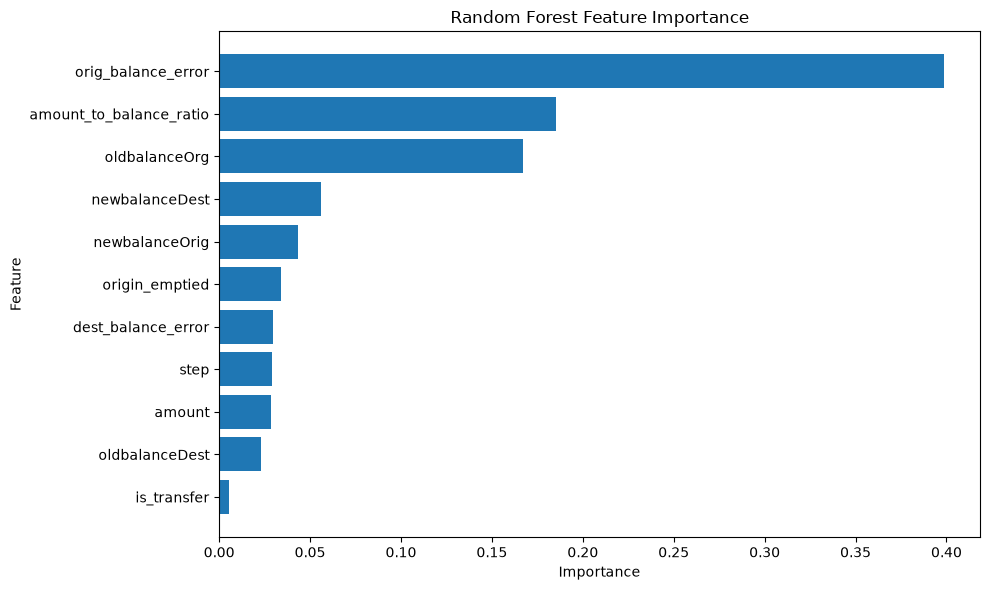

In [35]:
# ---------------------------------------------------------
# FEATURE IMPORTANCE VISUALIZATION
# ---------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [36]:
# ---------------------------------------------------------
# ABLATION TEST
# Remove engineered balance features
# ---------------------------------------------------------

features_to_remove = [
    "orig_balance_error",
    "dest_balance_error",
    "amount_to_balance_ratio",
    "origin_emptied"
]

X_train_reduced = X_train.drop(
    columns=features_to_remove
)

X_test_reduced = X_test.drop(
    columns=features_to_remove
)

print("Original features:")
print(list(X_train.columns))

print("\nReduced features:")
print(list(X_train_reduced.columns))

print("\nOriginal shape:", X_train.shape)
print("Reduced shape :", X_train_reduced.shape)

Original features:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_error', 'dest_balance_error', 'origin_emptied', 'amount_to_balance_ratio', 'is_transfer']

Reduced features:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'is_transfer']

Original shape: (2216327, 11)
Reduced shape : (2216327, 7)


In [37]:
# ---------------------------------------------------------
# RANDOM FOREST — REDUCED FEATURE SET
# ---------------------------------------------------------

rf_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

print("Training reduced Random Forest...")

rf_reduced.fit(
    X_train_reduced,
    y_train
)

print("Training complete.")

Training reduced Random Forest...
Training complete.


In [38]:
# ---------------------------------------------------------
# REDUCED RANDOM FOREST PREDICTIONS
# ---------------------------------------------------------

rf_reduced_predictions = rf_reduced.predict(
    X_test_reduced
)

rf_reduced_probabilities = rf_reduced.predict_proba(
    X_test_reduced
)[:, 1]

print("Predictions generated.")

Predictions generated.


In [39]:
# ---------------------------------------------------------
# REDUCED RANDOM FOREST EVALUATION
# ---------------------------------------------------------

reduced_accuracy = accuracy_score(
    y_test,
    rf_reduced_predictions
)

reduced_precision = precision_score(
    y_test,
    rf_reduced_predictions
)

reduced_recall = recall_score(
    y_test,
    rf_reduced_predictions
)

reduced_f1 = f1_score(
    y_test,
    rf_reduced_predictions
)

reduced_roc_auc = roc_auc_score(
    y_test,
    rf_reduced_probabilities
)

reduced_pr_auc = average_precision_score(
    y_test,
    rf_reduced_probabilities
)

reduced_cm = confusion_matrix(
    y_test,
    rf_reduced_predictions
)

print("RANDOM FOREST — REDUCED FEATURES")
print("-" * 45)

print(f"Accuracy : {reduced_accuracy:.4f}")
print(f"Precision: {reduced_precision:.4f}")
print(f"Recall   : {reduced_recall:.4f}")
print(f"F1 Score : {reduced_f1:.4f}")
print(f"ROC-AUC  : {reduced_roc_auc:.4f}")
print(f"PR-AUC   : {reduced_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(reduced_cm)

RANDOM FOREST — REDUCED FEATURES
---------------------------------------------
Accuracy : 0.9959
Precision: 0.4173
Recall   : 0.9264
F1 Score : 0.5754
ROC-AUC  : 0.9979
PR-AUC   : 0.9069

Confusion Matrix:
[[550314   2125]
 [   121   1522]]


In [40]:
# ---------------------------------------------------------
# THRESHOLD ANALYSIS — REDUCED RANDOM FOREST
# ---------------------------------------------------------

import numpy as np
import pandas as pd

thresholds = [
    0.10, 0.20, 0.30, 0.40, 0.50,
    0.60, 0.70, 0.80, 0.90
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        rf_reduced_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives
0,0.1,0.066798,0.993914,0.125182,1633,22814,10,529625
1,0.2,0.113890,0.986610,0.204208,1621,12612,22,539827
2,0.3,0.181612,0.975046,0.306193,1602,7219,41,545220
3,0.4,0.284599,0.953743,0.438383,1567,3939,76,548500
4,0.5,0.417329,0.926354,0.575425,1522,2125,121,550314
5,0.6,0.598138,0.899574,0.718522,1478,993,165,551446
6,0.7,0.788613,0.851491,0.818847,1399,375,244,552064
7,0.8,0.927465,0.801582,0.859941,1317,103,326,552336
8,0.9,0.993453,0.738892,0.847469,1214,8,429,552431


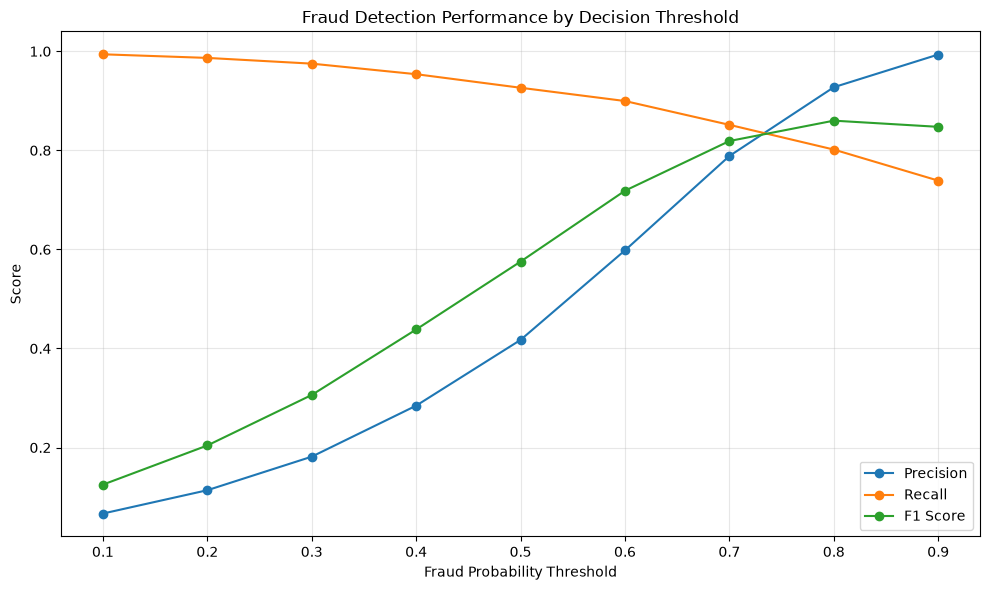

In [41]:
# ---------------------------------------------------------
# THRESHOLD PERFORMANCE VISUALIZATION
# ---------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Fraud Probability Threshold")
plt.ylabel("Score")
plt.title("Fraud Detection Performance by Decision Threshold")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [42]:
# ---------------------------------------------------------
# SELECT OPERATING THRESHOLD
# ---------------------------------------------------------

selected_threshold = 0.80

final_predictions = (
    rf_reduced_probabilities >= selected_threshold
).astype(int)

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

tn, fp, fn, tp = final_cm.ravel()

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

print("SELECTED FRAUD DETECTION MODEL")
print("-" * 45)

print(f"Model     : Reduced Random Forest")
print(f"Threshold : {selected_threshold:.2f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

print("\nOperational results:")
print(f"Fraud detected        : {tp}")
print(f"Fraud missed          : {fn}")
print(f"False fraud alerts    : {fp}")
print(f"Legitimate correctly  : {tn}")

print("\nConfusion Matrix:")
print(final_cm)

SELECTED FRAUD DETECTION MODEL
---------------------------------------------
Model     : Reduced Random Forest
Threshold : 0.80
Precision : 0.9275
Recall    : 0.8016
F1 Score  : 0.8599

Operational results:
Fraud detected        : 1317
Fraud missed          : 326
False fraud alerts    : 103
Legitimate correctly  : 552336

Confusion Matrix:
[[552336    103]
 [   326   1317]]


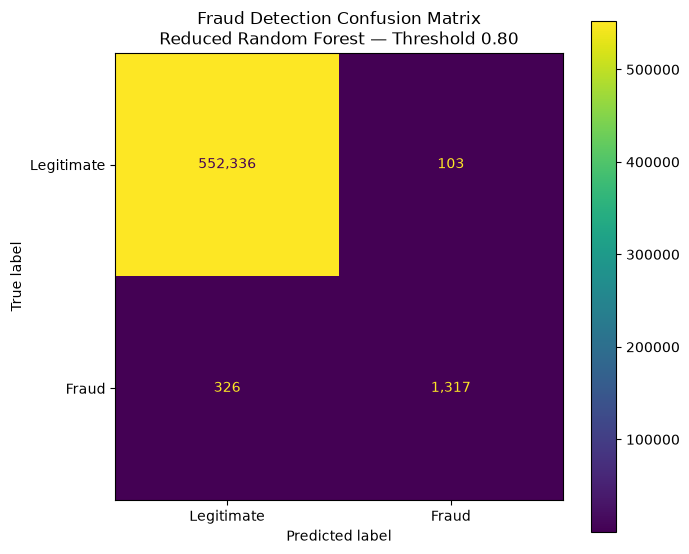

In [43]:
# ---------------------------------------------------------
# FINAL CONFUSION MATRIX
# ---------------------------------------------------------

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Legitimate", "Fraud"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format=",d"
)

plt.title(
    "Fraud Detection Confusion Matrix\n"
    "Reduced Random Forest — Threshold 0.80"
)

plt.tight_layout()
plt.show()

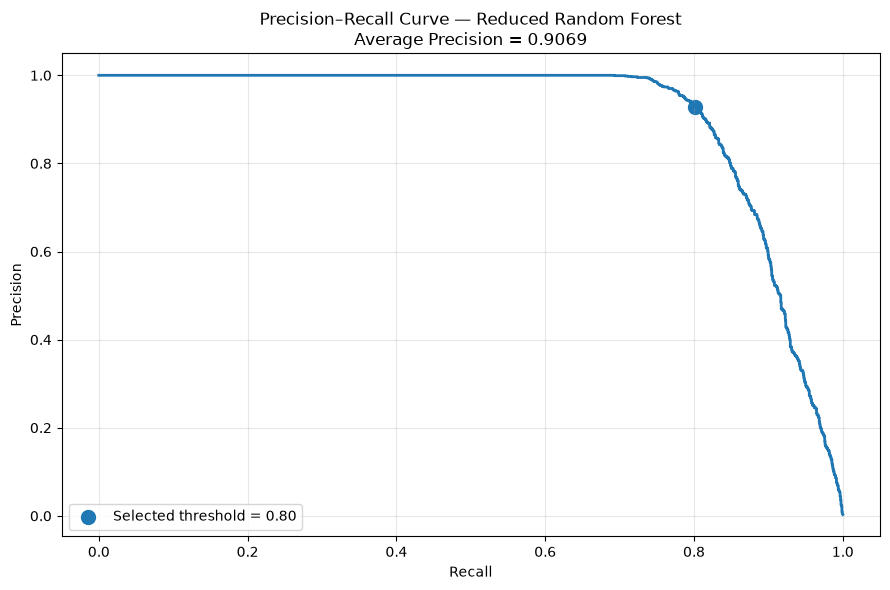

Average Precision: 0.9069
Selected threshold: 0.80
Selected precision: 0.9275
Selected recall: 0.8016


In [44]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Precision-recall curve
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_test,
    rf_reduced_probabilities
)

average_precision = average_precision_score(
    y_test,
    rf_reduced_probabilities
)

plt.figure(figsize=(9, 6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

# Mark our selected operating point
plt.scatter(
    final_recall,
    final_precision,
    s=100,
    label="Selected threshold = 0.80"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"Precision–Recall Curve — Reduced Random Forest\n"
    f"Average Precision = {average_precision:.4f}"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Precision: {average_precision:.4f}")
print(f"Selected threshold: {selected_threshold:.2f}")
print(f"Selected precision: {final_precision:.4f}")
print(f"Selected recall: {final_recall:.4f}")

REDUCED RANDOM FOREST — FEATURE IMPORTANCE


,feature,importance,importance_pct
0,oldbalanceOrg,0.371391,37.14
1,newbalanceDest,0.173737,17.37
2,amount,0.141934,14.19
3,step,0.107923,10.79
4,oldbalanceDest,0.105377,10.54
5,newbalanceOrig,0.059683,5.97
6,is_transfer,0.039954,4.00


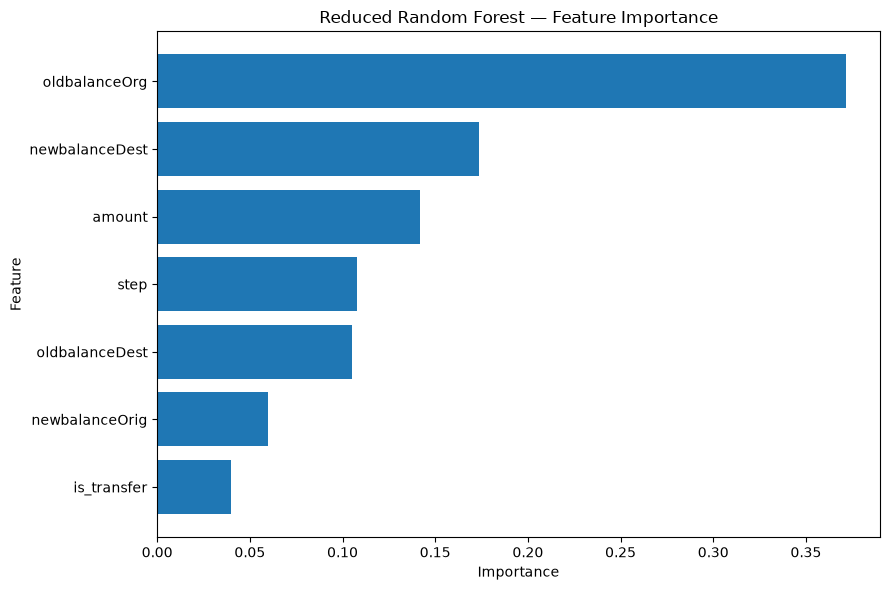

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance from reduced Random Forest
reduced_importance = pd.DataFrame({
    "feature": X_train_reduced.columns,
    "importance": rf_reduced.feature_importances_
})

# Sort from most important to least important
reduced_importance = (
    reduced_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# Convert importance to percentage
reduced_importance["importance_pct"] = (
    reduced_importance["importance"] * 100
).round(2)

print("REDUCED RANDOM FOREST — FEATURE IMPORTANCE")
print("=" * 50)

display(reduced_importance)

# Plot
plot_data = reduced_importance.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data["feature"],
    plot_data["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Reduced Random Forest — Feature Importance")

plt.tight_layout()
plt.show()

In [46]:
from pathlib import Path
import joblib

# Project model directory
model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

# Save trained reduced Random Forest
model_path = model_dir / "fraud_detection_random_forest.joblib"

joblib.dump(rf_reduced, model_path)

# Save metadata needed to reproduce predictions
metadata = {
    "features": list(X_train_reduced.columns),
    "threshold": selected_threshold,
    "model": "Reduced Random Forest",
    "precision": final_precision,
    "recall": final_recall,
    "f1_score": final_f1
}

metadata_path = model_dir / "model_metadata.joblib"
joblib.dump(metadata, metadata_path)

print("MODEL SAVED SUCCESSFULLY")
print("=" * 50)

print(f"Model:    {model_path}")
print(f"Metadata: {metadata_path}")

print("\nSaved metadata:")
for key, value in metadata.items():
    print(f"{key}: {value}")

MODEL SAVED SUCCESSFULLY
Model:    ../models/fraud_detection_random_forest.joblib
Metadata: ../models/model_metadata.joblib

Saved metadata:
features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'is_transfer']
threshold: 0.8
model: Reduced Random Forest
precision: 0.9274647887323944
recall: 0.8015824710894704
f1_score: 0.8599412340842312


In [47]:
import joblib
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Reload model and metadata from disk
loaded_model = joblib.load(
    "../models/fraud_detection_random_forest.joblib"
)

loaded_metadata = joblib.load(
    "../models/model_metadata.joblib"
)

print("MODEL RELOADED SUCCESSFULLY")
print("=" * 50)

print(f"Model: {loaded_metadata['model']}")
print(f"Threshold: {loaded_metadata['threshold']}")
print(f"Features: {loaded_metadata['features']}")

# Ensure feature order exactly matches training
X_test_loaded = X_test[
    loaded_metadata["features"]
]

# Generate probabilities using reloaded model
loaded_probabilities = loaded_model.predict_proba(
    X_test_loaded
)[:, 1]

# Apply saved operational threshold
loaded_predictions = (
    loaded_probabilities >= loaded_metadata["threshold"]
).astype(int)

# Evaluate
loaded_precision = precision_score(
    y_test,
    loaded_predictions
)

loaded_recall = recall_score(
    y_test,
    loaded_predictions
)

loaded_f1 = f1_score(
    y_test,
    loaded_predictions
)

loaded_cm = confusion_matrix(
    y_test,
    loaded_predictions
)

print("\nRELOADED MODEL PERFORMANCE")
print("=" * 50)

print(f"Precision: {loaded_precision:.4f}")
print(f"Recall   : {loaded_recall:.4f}")
print(f"F1 Score : {loaded_f1:.4f}")

print("\nConfusion Matrix:")
print(loaded_cm)

# Verify predictions are identical
same_predictions = np.array_equal(
    final_predictions,
    loaded_predictions
)

print(
    "\nPredictions identical to original model:",
    same_predictions
)

MODEL RELOADED SUCCESSFULLY
Model: Reduced Random Forest
Threshold: 0.8
Features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'is_transfer']

RELOADED MODEL PERFORMANCE
Precision: 0.9275
Recall   : 0.8016
F1 Score : 0.8599

Confusion Matrix:
[[552336    103]
 [   326   1317]]

Predictions identical to original model: True


In [1]:
# ============================================================
# EXPORT PORTFOLIO FIGURES
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)

figures_dir = Path("../reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

print("Saving portfolio figures to:", figures_dir.resolve())

Saving portfolio figures to: /Users/kunalsingh/banking-fraud-analytics/reports/figures


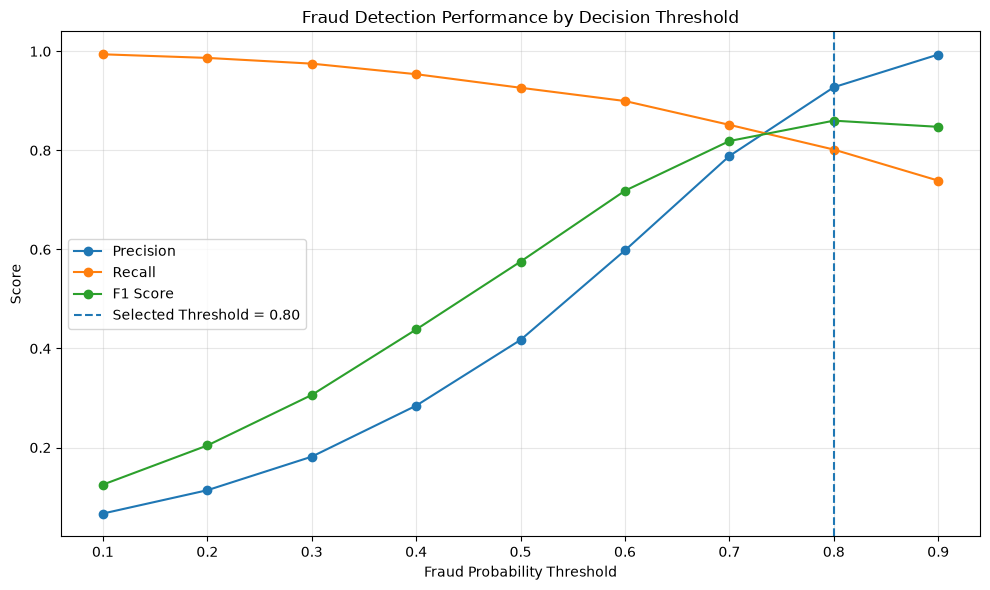

Saved: ../reports/figures/threshold_performance.png


In [3]:
# ============================================================
# FIGURE 1 — DECISION THRESHOLD PERFORMANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Recreate threshold results from our completed experiment
threshold_results = pd.DataFrame({
    "threshold": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    "precision": [
        0.066798, 0.113890, 0.181612,
        0.284599, 0.417329, 0.598138,
        0.788613, 0.927465, 0.993453
    ],
    "recall": [
        0.993914, 0.986610, 0.975046,
        0.953743, 0.926354, 0.899574,
        0.851491, 0.801582, 0.738892
    ],
    "f1": [
        0.125182, 0.204208, 0.306193,
        0.438383, 0.575425, 0.718522,
        0.818847, 0.859941, 0.847469
    ]
})

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    x=0.80,
    linestyle="--",
    label="Selected Threshold = 0.80"
)

plt.xlabel("Fraud Probability Threshold")
plt.ylabel("Score")
plt.title("Fraud Detection Performance by Decision Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

output_path = figures_dir / "threshold_performance.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

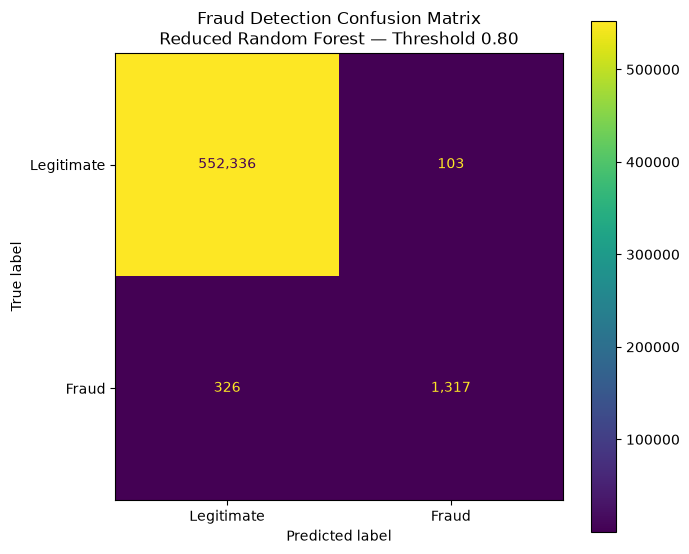

Saved: ../reports/figures/confusion_matrix.png


In [4]:
# ============================================================
# FIGURE 2 — FINAL CONFUSION MATRIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Final confusion matrix from selected threshold = 0.80
final_cm = np.array([
    [552336, 103],
    [326, 1317]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Legitimate", "Fraud"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format=",d"
)

plt.title(
    "Fraud Detection Confusion Matrix\n"
    "Reduced Random Forest — Threshold 0.80"
)

plt.tight_layout()

output_path = figures_dir / "confusion_matrix.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

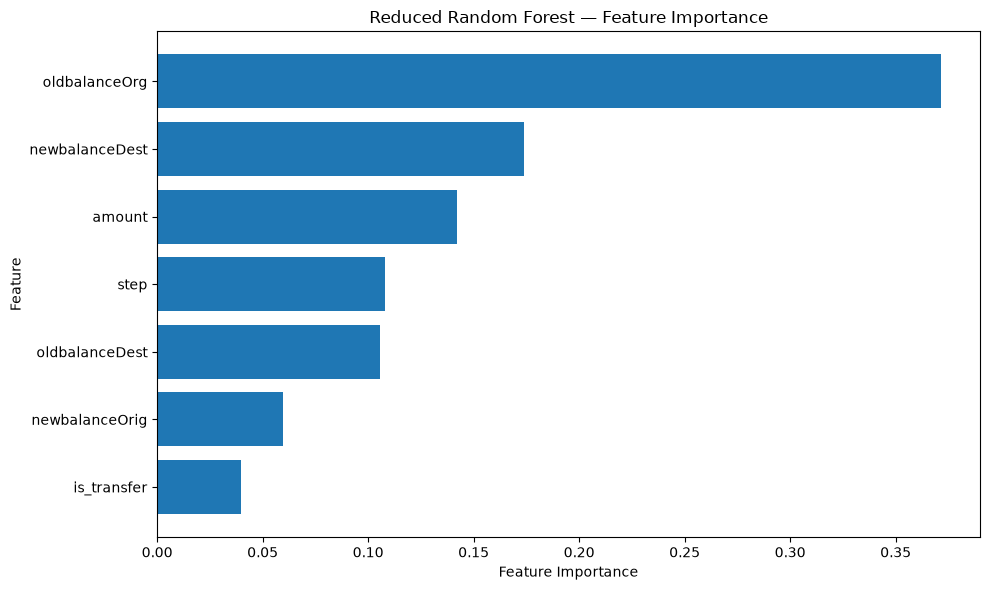

Saved: ../reports/figures/feature_importance.png


In [5]:
# ============================================================
# FIGURE 3 — REDUCED RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": [
        "oldbalanceOrg",
        "newbalanceDest",
        "amount",
        "step",
        "oldbalanceDest",
        "newbalanceOrig",
        "is_transfer"
    ],
    "importance": [
        0.371391,
        0.173737,
        0.141934,
        0.107923,
        0.105377,
        0.059683,
        0.039954
    ]
})

# Sort ascending for horizontal bar chart
plot_data = feature_importance.sort_values("importance")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["feature"],
    plot_data["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Reduced Random Forest — Feature Importance")

plt.tight_layout()

output_path = figures_dir / "feature_importance.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

In [6]:
# ============================================================
# EXPORT THRESHOLD RESULTS
# ============================================================

from pathlib import Path

results_dir = Path("../reports/results")
results_dir.mkdir(parents=True, exist_ok=True)

threshold_export = threshold_results.copy()

threshold_export.to_csv(
    results_dir / "threshold_results.csv",
    index=False
)

print("Saved:", results_dir / "threshold_results.csv")

threshold_export

Saved: ../reports/results/threshold_results.csv


,threshold,precision,recall,f1
0,0.1,0.066798,0.993914,0.125182
1,0.2,0.113890,0.986610,0.204208
2,0.3,0.181612,0.975046,0.306193
3,0.4,0.284599,0.953743,0.438383
4,0.5,0.417329,0.926354,0.575425
5,0.6,0.598138,0.899574,0.718522
6,0.7,0.788613,0.851491,0.818847
7,0.8,0.927465,0.801582,0.859941
8,0.9,0.993453,0.738892,0.847469


In [7]:
# ============================================================
# EXPORT FINAL MODEL PERFORMANCE
# ============================================================

import pandas as pd

final_model_results = pd.DataFrame([{
    "model": "Reduced Random Forest",
    "threshold": 0.80,
    "precision": 0.9275,
    "recall": 0.8016,
    "f1_score": 0.8599,
    "true_negatives": 552336,
    "false_positives": 103,
    "false_negatives": 326,
    "true_positives": 1317
}])

output_path = results_dir / "final_model_performance.csv"

final_model_results.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

final_model_results

Saved: ../reports/results/final_model_performance.csv


,model,threshold,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,Reduced Random Forest,0.8,0.9275,0.8016,0.8599,552336,103,326,1317
